In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

plt.style.use("ggplot")


pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/traffic_cleaned_final.csv")

roads = [6,9,93]

traffic = df[df["Str_Nr"].isin(roads)].copy()

traffic = traffic.dropna(
    subset=[
        "DTV_Kfz_W_Q",
        "DTV_SV_W_Q",
        "pSV_W_Q"
    ]
)

traffic.shape

C:\Users\vikhy\AppData\Local\Temp\ipykernel_19752\4118181267.py:1: DtypeWarning: Columns (0: Ri_MSV30maxRi_Kfz_MobisSo, 1: Ri_MSV30maxRi_Kfz_W, 2: Ri_MSV30maxRi_Kfz_U, 3: Ri_MSV30maxRi_Kfz_S, 4: DL_Q, 5: bSV30_MobisSo_Ri1, 6: bSV30_MobisSo_Ri2, 7: bSV30_W_Ri1, 8: bSV30_W_Ri2, 9: bSV30_U_Ri1, 10: bSV30_U_Ri2, 11: bSV30_S_Ri1, 12: bSV30_S_Ri2, 13: bSV50_MobisSo_Ri1, 14: bSV50_MobisSo_Ri2, 15: bLkwK50_MobisSo_Ri1, 16: bLkwK50_MobisSo_Ri2, 17: Abschnitt_Ast, 18: Station, 19: Ausrichtung) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/traffic_cleaned_final.csv")


(2303, 252)

In [4]:
print("="*60)

print("CORRELATION DATASET")

print("="*60)

print("Rows :",len(traffic))

print("Roads :",traffic["Str_Nr"].unique())

print("Years :",traffic["Jahr"].min(),"-",traffic["Jahr"].max())

CORRELATION DATASET
Rows : 2303
Roads : [ 6  9 93]
Years : 2003 - 2023


In [5]:
corr_df = traffic[
    [
        "Jahr",
        "Str_Nr",
        "DTV_Kfz_W_Q",
        "DTV_SV_W_Q",
        "pSV_W_Q",
        "Anz_Fs_Q",
        "Betriebs_km"
    ]
]

corr_df.head()

,Jahr,Str_Nr,DTV_Kfz_W_Q,DTV_SV_W_Q,pSV_W_Q,Anz_Fs_Q,Betriebs_km
286,2023,6,34.590,10.793,31.2,4,803.0
287,2023,6,49.521,16.978,34.3,4,715.9
291,2023,6,43.997,7.527,17.1,4,660.3
292,2023,6,43.679,11.893,27.2,4,794.7
293,2023,6,77.191,20.852,27.0,6,791.7


In [6]:
corr = corr_df.corr(numeric_only=True)

corr.round(3)

,Jahr,Str_Nr,DTV_Kfz_W_Q,DTV_SV_W_Q,pSV_W_Q,Anz_Fs_Q,Betriebs_km
Jahr,1.000,-0.039,0.012,-0.004,0.136,0.072,0.058
Str_Nr,-0.039,1.000,-0.101,0.003,-0.048,-0.101,-0.355
DTV_Kfz_W_Q,0.012,-0.101,1.000,-0.348,0.018,0.793,0.252
DTV_SV_W_Q,-0.004,0.003,-0.348,1.000,-0.339,-0.420,-0.234
pSV_W_Q,0.136,-0.048,0.018,-0.339,1.000,0.254,0.510
Anz_Fs_Q,0.072,-0.101,0.793,-0.420,0.254,1.000,0.163
Betriebs_km,0.058,-0.355,0.252,-0.234,0.510,0.163,1.000


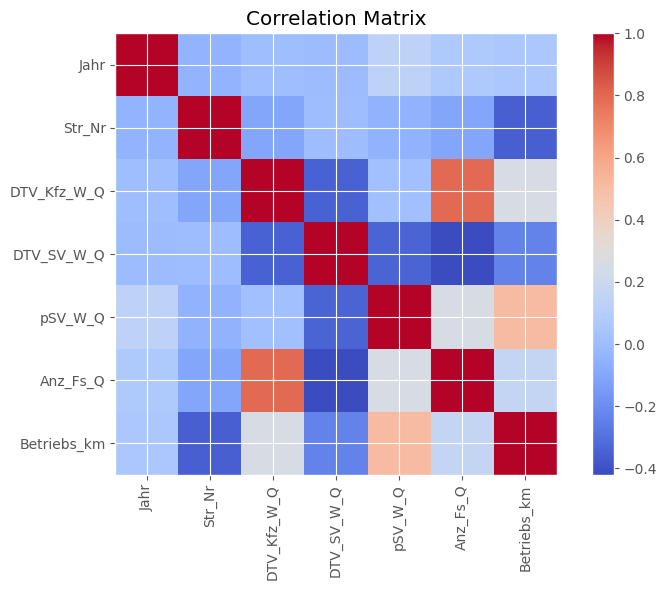

In [7]:
plt.figure(figsize=(8,6))

plt.imshow(corr,cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [8]:
print(corr)

                 Jahr    Str_Nr  DTV_Kfz_W_Q  DTV_SV_W_Q   pSV_W_Q  Anz_Fs_Q  \
Jahr         1.000000 -0.039115     0.012309   -0.003570  0.135670  0.071681   
Str_Nr      -0.039115  1.000000    -0.101468    0.003049 -0.048182 -0.100660   
DTV_Kfz_W_Q  0.012309 -0.101468     1.000000   -0.347742  0.018478  0.793348   
DTV_SV_W_Q  -0.003570  0.003049    -0.347742    1.000000 -0.338863 -0.419871   
pSV_W_Q      0.135670 -0.048182     0.018478   -0.338863  1.000000  0.254052   
Anz_Fs_Q     0.071681 -0.100660     0.793348   -0.419871  0.254052  1.000000   
Betriebs_km  0.057704 -0.355408     0.252098   -0.234315  0.509990  0.163098   

             Betriebs_km  
Jahr            0.057704  
Str_Nr         -0.355408  
DTV_Kfz_W_Q     0.252098  
DTV_SV_W_Q     -0.234315  
pSV_W_Q         0.509990  
Anz_Fs_Q        0.163098  
Betriebs_km     1.000000  


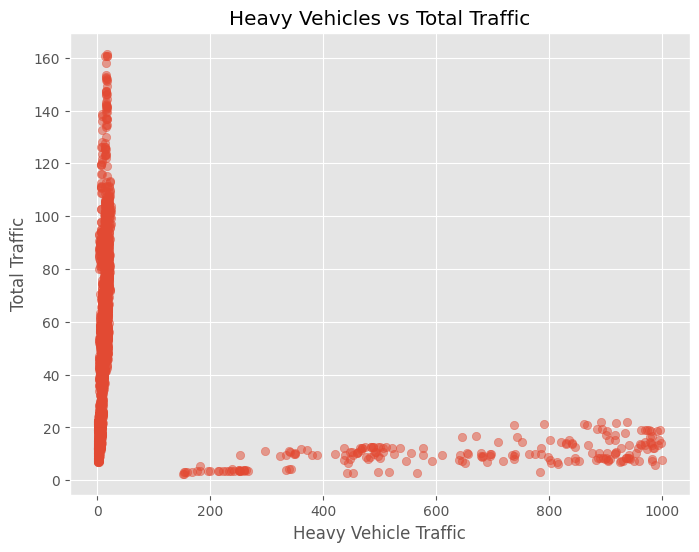

In [ ]:
#Total Traffic vs Heavy Vehicles
plt.figure(figsize=(8,6))

plt.scatter(
    traffic["DTV_SV_W_Q"],
    traffic["DTV_Kfz_W_Q"],
    alpha=0.5
)

plt.xlabel("Heavy Vehicle Traffic")

plt.ylabel("Total Traffic")

plt.title("Heavy Vehicles vs Total Traffic")

plt.show()

In [10]:
#pearson Correlation Coefficient
r,p = pearsonr(
    traffic["DTV_SV_W_Q"],
    traffic["DTV_Kfz_W_Q"]
)

print("Pearson Correlation :",round(r,3))

print("P-value :",p)

Pearson Correlation : -0.348
P-value : 1.9071375507761905e-66


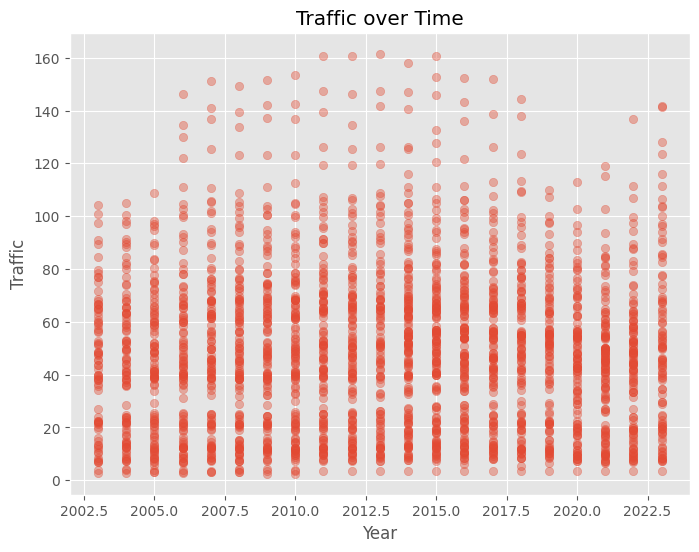

In [11]:
#year vs Total Traffic
plt.figure(figsize=(8,6))

plt.scatter(
    traffic["Jahr"],
    traffic["DTV_Kfz_W_Q"],
    alpha=0.4
)

plt.xlabel("Year")

plt.ylabel("Traffic")

plt.title("Traffic over Time")

plt.show()

In [12]:
r,p = pearsonr(
    traffic["Jahr"],
    traffic["DTV_Kfz_W_Q"]
)

print(r)

print(p)

0.012309264928765504
0.5549103491488463


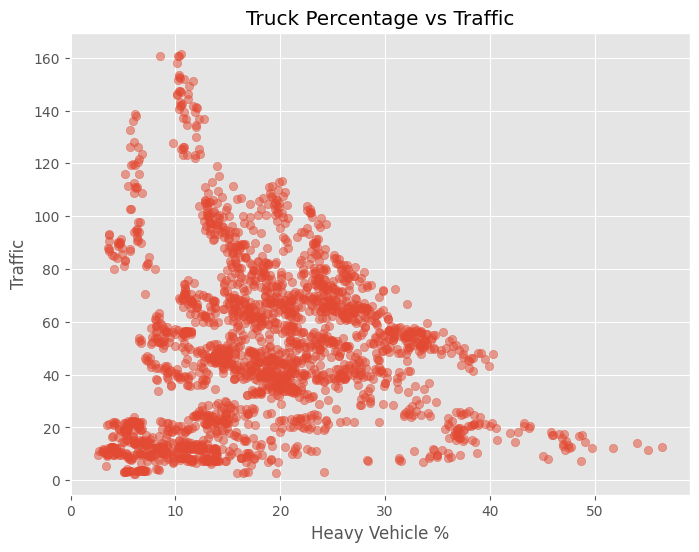

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    traffic["pSV_W_Q"],
    traffic["DTV_Kfz_W_Q"],
    alpha=0.5
)

plt.xlabel("Heavy Vehicle %")

plt.ylabel("Traffic")

plt.title("Truck Percentage vs Traffic")

plt.show()

In [14]:
r,p = pearsonr(
    traffic["pSV_W_Q"],
    traffic["DTV_Kfz_W_Q"]
)

print(r)

print(p)

0.018477770767229097
0.37543716999073773


<Figure size 800x600 with 0 Axes>

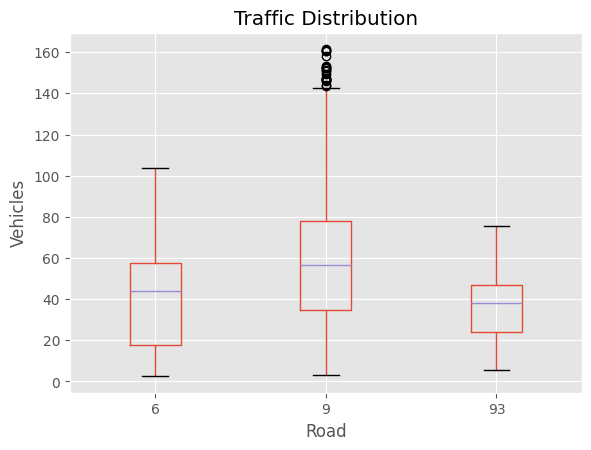

In [15]:
plt.figure(figsize=(8,6))

traffic.boxplot(
    column="DTV_Kfz_W_Q",
    by="Str_Nr"
)

plt.title("Traffic Distribution")

plt.suptitle("")

plt.xlabel("Road")

plt.ylabel("Vehicles")

plt.show()

<Figure size 800x600 with 0 Axes>

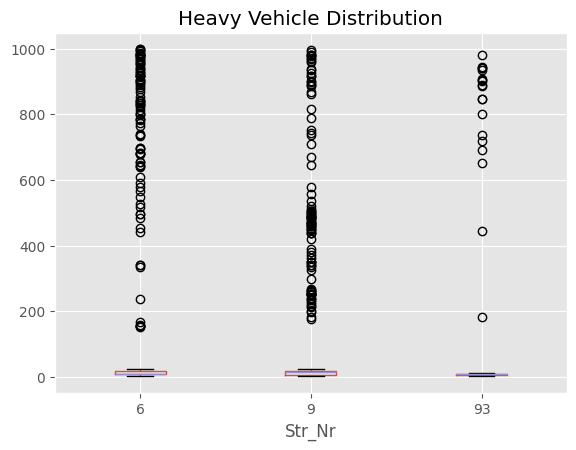

In [16]:
#heavy vehicle distribution

plt.figure(figsize=(8,6))

traffic.boxplot(
    column="DTV_SV_W_Q",
    by="Str_Nr"
)

plt.title("Heavy Vehicle Distribution")

plt.suptitle("")

plt.show()

In [17]:
summary = (
    traffic
    .groupby("Str_Nr")
    [
        [
            "DTV_Kfz_W_Q",
            "DTV_SV_W_Q",
            "pSV_W_Q"
        ]
    ]
    .mean()
)

summary

,DTV_Kfz_W_Q,DTV_SV_W_Q,pSV_W_Q
Str_Nr,,,
6,41.886709,79.070762,20.994646
9,58.192754,58.180250,16.191220
93,38.718351,72.034082,17.469697


In [18]:
variation = (
    traffic
    .groupby("Str_Nr")
    [
        "DTV_Kfz_W_Q"
    ]
    .std()
)

variation

Str_Nr
6     24.473674
9     34.433986
93    18.428186
Name: DTV_Kfz_W_Q, dtype: float64

In [20]:
results = pd.DataFrame({

    "Correlation":[
        corr.loc[
            "DTV_Kfz_W_Q",
            "DTV_SV_W_Q"
        ],

        corr.loc[
            "DTV_Kfz_W_Q",
            "pSV_W_Q"
        ],

        corr.loc[
            "Jahr",
            "DTV_Kfz_W_Q"
        ]
    ]

},
index=[

"Traffic vs Heavy Vehicles",

"Traffic vs Truck %",

"Year vs Traffic"

])

results

,Correlation
Traffic vs Heavy Vehicles,-0.347742
Traffic vs Truck %,0.018478
Year vs Traffic,0.012309


In [21]:
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

for idx,row in results.iterrows():

    r = row["Correlation"]

    if abs(r)>=0.8:
        strength="Very Strong"

    elif abs(r)>=0.6:
        strength="Strong"

    elif abs(r)>=0.4:
        strength="Moderate"

    elif abs(r)>=0.2:
        strength="Weak"

    else:
        strength="Very Weak"

    print(f"{idx}: {strength} correlation ({r:.3f})")

CORRELATION ANALYSIS
Traffic vs Heavy Vehicles: Weak correlation (-0.348)
Traffic vs Truck %: Very Weak correlation (0.018)
Year vs Traffic: Very Weak correlation (0.012)


In [22]:
results.to_csv("../results/correlation_summary.csv")

summary.to_csv("../results/road_statistics.csv")

In [23]:
from scipy.stats import linregress

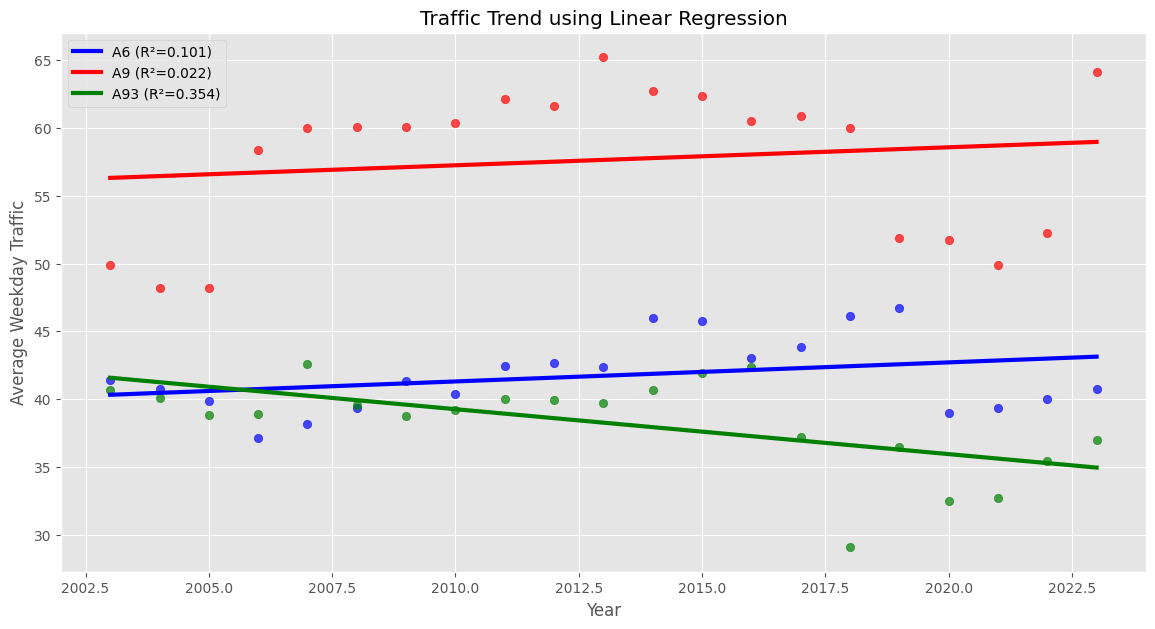

In [24]:
plt.figure(figsize=(14,7))

colors = {
    6: "blue",
    9: "red",
    93: "green"
}

for road in [6, 9, 93]:

    road_data = (
        traffic[traffic["Str_Nr"] == road]
        .groupby("Jahr")["DTV_Kfz_W_Q"]
        .mean()
        .reset_index()
    )

    x = road_data["Jahr"]
    y = road_data["DTV_Kfz_W_Q"]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    plt.scatter(
        x,
        y,
        color=colors[road],
        alpha=0.7
    )

    plt.plot(
        x,
        intercept + slope*x,
        color=colors[road],
        linewidth=3,
        label=f"A{road} (R²={r_value**2:.3f})"
    )

plt.title("Traffic Trend using Linear Regression")

plt.xlabel("Year")

plt.ylabel("Average Weekday Traffic")

plt.legend()

plt.grid(True)

plt.show()

In [25]:
print("="*70)
print("LINEAR REGRESSION RESULTS")
print("="*70)

for road in [6,9,93]:

    road_data = (
        traffic[traffic["Str_Nr"]==road]
        .groupby("Jahr")["DTV_Kfz_W_Q"]
        .mean()
        .reset_index()
    )

    slope, intercept, r, p, std = linregress(
        road_data["Jahr"],
        road_data["DTV_Kfz_W_Q"]
    )

    print(f"\nA{road}")

    print(f"Slope       : {slope:.2f}")

    print(f"R²          : {r**2:.3f}")

    print(f"P-value     : {p:.5f}")

    if p < 0.05:
        print("Trend       : Statistically Significant")
    else:
        print("Trend       : Not Significant")

LINEAR REGRESSION RESULTS

A6
Slope       : 0.14
R²          : 0.101
P-value     : 0.15929
Trend       : Not Significant

A9
Slope       : 0.13
R²          : 0.022
P-value     : 0.52591
Trend       : Not Significant

A93
Slope       : -0.33
R²          : 0.354
P-value     : 0.00442
Trend       : Statistically Significant


In [26]:
road_results = []

for road in [6,9,93]:

    subset = traffic[
        traffic["Str_Nr"]==road
    ]

    r,p = pearsonr(
        subset["DTV_Kfz_W_Q"],
        subset["DTV_SV_W_Q"]
    )

    road_results.append({
        "Road":f"A{road}",
        "Correlation":r,
        "P-value":p
    })

road_corr = pd.DataFrame(road_results)

road_corr

,Road,Correlation,P-value
0,A6,-0.374954,2.101944e-34
1,A9,-0.348509,2.962289e-32
2,A93,-0.480414,9.671647e-15


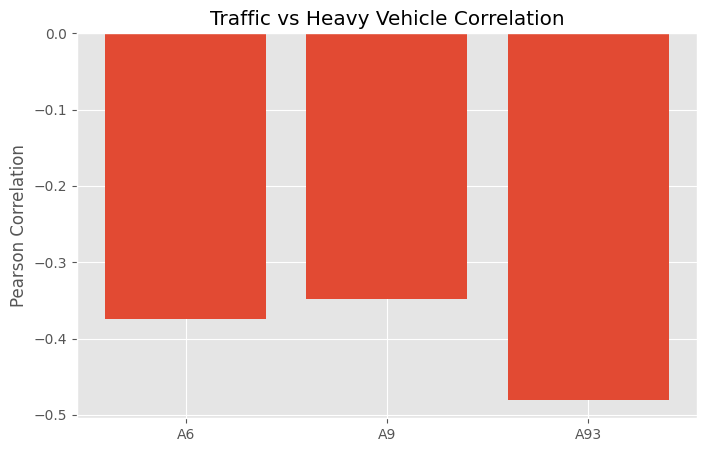

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    road_corr["Road"],
    road_corr["Correlation"]
)

plt.title("Traffic vs Heavy Vehicle Correlation")

plt.ylabel("Pearson Correlation")

plt.show()

In [28]:
for _, row in road_corr.iterrows():

    print("="*40)

    print(row["Road"])

    print("="*40)

    r = row["Correlation"]

    if abs(r)>0.8:

        print("Very Strong Relationship")

    elif abs(r)>0.6:

        print("Strong Relationship")

    elif abs(r)>0.4:

        print("Moderate Relationship")

    else:

        print("Weak Relationship")

    print(f"Correlation : {r:.3f}")

    print(f"P-value : {row['P-value']:.5f}")

A6
Weak Relationship
Correlation : -0.375
P-value : 0.00000
A9
Weak Relationship
Correlation : -0.349
P-value : 0.00000
A93
Moderate Relationship
Correlation : -0.480
P-value : 0.00000


In [29]:
corr_matrix = corr_df.corr(numeric_only=True)

pairs = []

for i in corr_matrix.columns:

    for j in corr_matrix.columns:

        if i != j:

            value = corr_matrix.loc[i,j]

            if abs(value)>=0.70:

                pairs.append([

                    i,

                    j,

                    value

                ])

network = pd.DataFrame(

    pairs,

    columns=[

        "Variable 1",

        "Variable 2",

        "Correlation"

    ]

)

network = network.drop_duplicates()

network

,Variable 1,Variable 2,Correlation
0,DTV_Kfz_W_Q,Anz_Fs_Q,0.793348
1,Anz_Fs_Q,DTV_Kfz_W_Q,0.793348


In [30]:
network.sort_values(

    "Correlation",

    ascending=False

)

,Variable 1,Variable 2,Correlation
0,DTV_Kfz_W_Q,Anz_Fs_Q,0.793348
1,Anz_Fs_Q,DTV_Kfz_W_Q,0.793348


In [31]:
print("="*60)

print("STRONG CORRELATIONS")

print("="*60)

for _, row in network.iterrows():

    print(

        f"{row['Variable 1']}"

        f" <--> "

        f"{row['Variable 2']}"

        f" = "

        f"{row['Correlation']:.3f}"

    )

STRONG CORRELATIONS
DTV_Kfz_W_Q <--> Anz_Fs_Q = 0.793
Anz_Fs_Q <--> DTV_Kfz_W_Q = 0.793


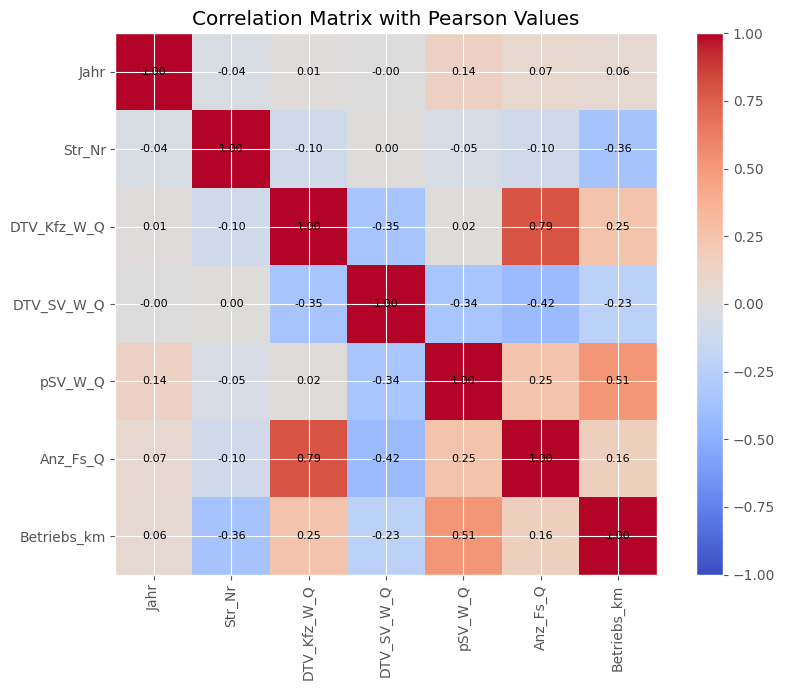

In [32]:
plt.figure(figsize=(9,7))

im = plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(im)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):

        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix with Pearson Values")

plt.tight_layout()

plt.show()

In [33]:
dashboard = pd.DataFrame({

    "Metric":[

        "Average Traffic",

        "Average Heavy Vehicles",

        "Average Truck %",

        "Traffic Std Dev",

        "Heavy Vehicle Correlation"

    ],

    "A6":[

        traffic[traffic.Str_Nr==6]["DTV_Kfz_W_Q"].mean(),

        traffic[traffic.Str_Nr==6]["DTV_SV_W_Q"].mean(),

        traffic[traffic.Str_Nr==6]["pSV_W_Q"].mean(),

        traffic[traffic.Str_Nr==6]["DTV_Kfz_W_Q"].std(),

        road_corr.loc[
            road_corr.Road=="A6",
            "Correlation"
        ].values[0]

    ],

    "A9":[

        traffic[traffic.Str_Nr==9]["DTV_Kfz_W_Q"].mean(),

        traffic[traffic.Str_Nr==9]["DTV_SV_W_Q"].mean(),

        traffic[traffic.Str_Nr==9]["pSV_W_Q"].mean(),

        traffic[traffic.Str_Nr==9]["DTV_Kfz_W_Q"].std(),

        road_corr.loc[
            road_corr.Road=="A9",
            "Correlation"
        ].values[0]

    ],

    "A93":[

        traffic[traffic.Str_Nr==93]["DTV_Kfz_W_Q"].mean(),

        traffic[traffic.Str_Nr==93]["DTV_SV_W_Q"].mean(),

        traffic[traffic.Str_Nr==93]["pSV_W_Q"].mean(),

        traffic[traffic.Str_Nr==93]["DTV_Kfz_W_Q"].std(),

        road_corr.loc[
            road_corr.Road=="A93",
            "Correlation"
        ].values[0]

    ]

})

dashboard

,Metric,A6,A9,A93
0,Average Traffic,41.886709,58.192754,38.718351
1,Average Heavy Vehicles,79.070762,58.180250,72.034082
2,Average Truck %,20.994646,16.191220,17.469697
3,Traffic Std Dev,24.473674,34.433986,18.428186
4,Heavy Vehicle Correlation,-0.374954,-0.348509,-0.480414
